# CNN Development on a Custom Dataset — Plant Leaf Disease Classification (Agriculture)

**Course:** CVPR — Mid Assignment (Summer 25-26)
**Student ID:** *(23-52978-3)*
**Dataset:** New Plant Diseases Dataset (Augmented PlantVillage) — Kaggle
**Domain:** Agriculture / Precision Farming — Plant Disease Recognition

---

### 1. Problem Statement & Dataset Justification

Plant diseases cause major crop losses, and manual leaf inspection is slow and unreliable.
This notebook builds a custom CNN in PyTorch to classify leaf images into **38 classes**
(healthy vs. diseased) across 14 crops (Apple, Corn, Tomato, Potato, Grape, etc.).

**Dataset:** [New Plant Diseases Dataset](https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset)
(Kaggle) — ~87,000 leaf images, already organized by class folder.

I chosen because it's a real multi-class problem, fits the agriculture-focused paper I plan to
write next, and is well-documented in existing research.


## 1. Import Libraries

In [1]:
import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_fscore_support, accuracy_score
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)


Using device: cuda


## 2. Load and Explore Dataset

The dataset is downloaded directly from Kaggle


In [2]:
import kagglehub

path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
print("Path to dataset files:", path)


Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Path to dataset files: /kaggle/input/new-plant-diseases-dataset


In [3]:
# The dataset extracts with a duplicated top-level folder name.
# We locate the actual train/valid ImageFolder directories.
base_dir = os.path.join(path, "New Plant Diseases Dataset(Augmented)",
                         "New Plant Diseases Dataset(Augmented)")

train_folder = os.path.join(base_dir, "train")
valid_folder = os.path.join(base_dir, "valid")

print("Train folder exists:", os.path.exists(train_folder))
print("Valid folder exists:", os.path.exists(valid_folder))


Train folder exists: True
Valid folder exists: True


**Note on train / validation / test split:**
I split data as:
train → 90% train / 10% val



In [4]:
class_names_probe = datasets.ImageFolder(train_folder)
num_classes = len(class_names_probe.classes)
print(f"Number of classes: {num_classes}")
print("First 10 classes:", class_names_probe.classes[:10])
print(f"Total images in train/: {len(class_names_probe)}")


Number of classes: 38
First 10 classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']
Total images in train/: 70295


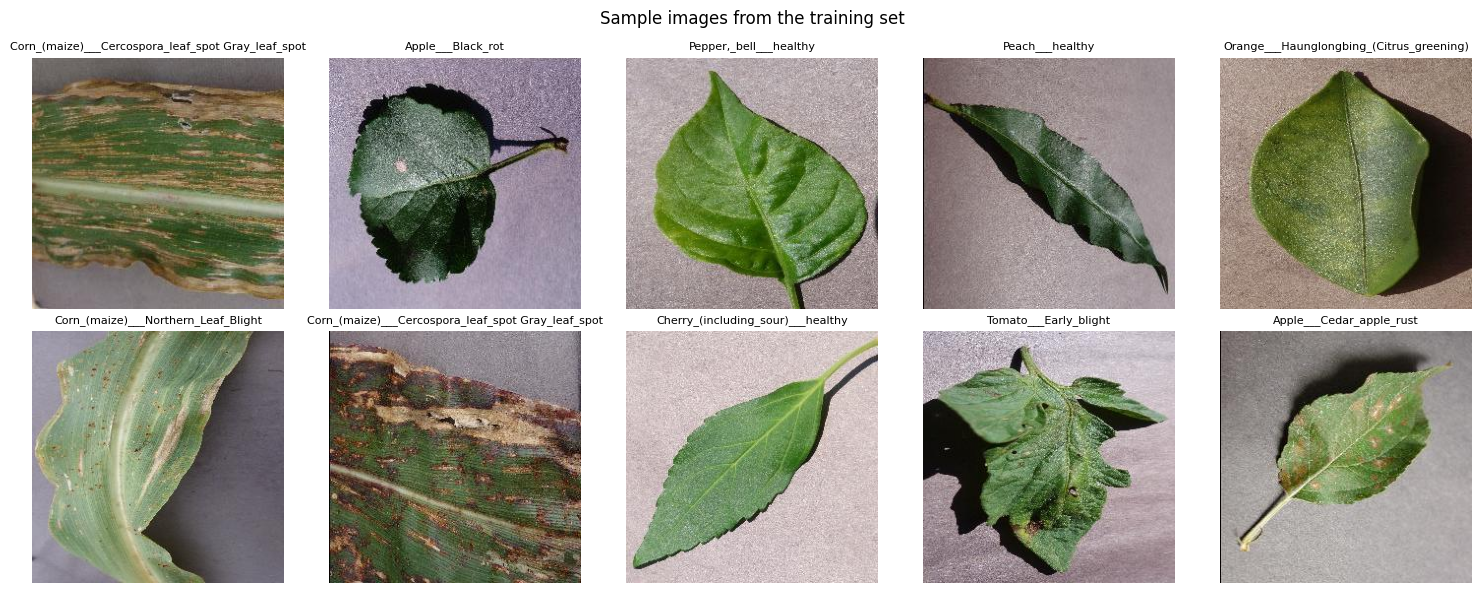

In [5]:
# Quick visual sanity check of a few samples across different classes
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
sample_indices = random.sample(range(len(class_names_probe)), 10)
for ax, idx in zip(axes.flat, sample_indices):
    img, label = class_names_probe[idx]
    ax.imshow(img)
    ax.set_title(class_names_probe.classes[label], fontsize=8)
    ax.axis('off')
plt.suptitle("Sample images from the training set")
plt.tight_layout()
plt.show()


## 3. Data Preprocessing & Augmentation




In [6]:
IMG_SIZE = 128
BATCH_SIZE = 64

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# Full train-folder dataset with augmentation (for the training split)
full_train_aug = datasets.ImageFolder(train_folder, transform=train_transform)
# Same folder, no augmentation (for the validation split, taken from the same images)
full_train_plain = datasets.ImageFolder(train_folder, transform=eval_transform)

class_names = full_train_aug.classes
num_classes = len(class_names)

# 90/10 split (indices only, applied to both versions of the dataset)
n_total = len(full_train_aug)
n_val = int(0.10 * n_total)
n_train = n_total - n_val

generator = torch.Generator().manual_seed(SEED)
train_subset, _ = random_split(full_train_aug, [n_train, n_val], generator=generator)
generator = torch.Generator().manual_seed(SEED)  # same seed -> same split, plain transform
_, val_subset = random_split(full_train_plain, [n_train, n_val], generator=generator)

test_data = datasets.ImageFolder(valid_folder, transform=eval_transform)

print(f"Train images:      {len(train_subset)}")
print(f"Validation images: {len(val_subset)}")
print(f"Test images:        {len(test_data)}")
print(f"Classes:            {num_classes}")


Train images:      63266
Validation images: 7029
Test images:        17572
Classes:            38


In [7]:
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)


##4. Define CNN Architecture




In [8]:
class PlantDiseaseCNN(nn.Module):
    def __init__(self, num_classes):
        super(PlantDiseaseCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1: 3 -> 32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),

            # Block 2: 32 -> 64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),

            # Block 3: 64 -> 128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3),

            # Block 4: 128 -> 256
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.4),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Training setup:



In [9]:
EPOCHS = 20
LEARNING_RATE = 1e-3
MIN_LEARNING_RATE = 1e-5

model = PlantDiseaseCNN(num_classes).to(device)
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=MIN_LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

from torchsummary import summary
summary(model, input_size=(3, IMG_SIZE, IMG_SIZE))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
       BatchNorm2d-2         [-1, 32, 128, 128]              64
              ReLU-3         [-1, 32, 128, 128]               0
            Conv2d-4         [-1, 32, 128, 128]           9,248
       BatchNorm2d-5         [-1, 32, 128, 128]              64
              ReLU-6         [-1, 32, 128, 128]               0
         MaxPool2d-7           [-1, 32, 64, 64]               0
         Dropout2d-8           [-1, 32, 64, 64]               0
            Conv2d-9           [-1, 64, 64, 64]          18,496
      BatchNorm2d-10           [-1, 64, 64, 64]             128
             ReLU-11           [-1, 64, 64, 64]               0
           Conv2d-12           [-1, 64, 64, 64]          36,928
      BatchNorm2d-13           [-1, 64, 64, 64]             128
             ReLU-14           [-1, 64,

## 5. Training Loop with Validation

In [10]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


@torch.no_grad()
def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


In [11]:
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []
best_val_acc = 0.0
BEST_MODEL_PATH = "best_plant_disease_cnn.pth"

for epoch in range(EPOCHS):
    print("----------------------------------------------------")
    print(f"Epoch {epoch+1}/{EPOCHS}, LR: {optimizer.param_groups[0]['lr']:.6g}")

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    scheduler.step()

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    # Save the best-performing checkpoint (by validation accuracy)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  -> New best model saved (val_acc={val_acc:.4f})")

print(f"\nBest validation accuracy achieved: {best_val_acc:.4f}")


----------------------------------------------------
Epoch 1/20, LR: 0.001
Train Loss: 1.5744 | Train Acc: 0.5326
Val Loss:   0.6770 | Val Acc:   0.7919
  -> New best model saved (val_acc=0.7919)
----------------------------------------------------
Epoch 2/20, LR: 0.000993906
Train Loss: 0.8679 | Train Acc: 0.7275
Val Loss:   0.3717 | Val Acc:   0.8850
  -> New best model saved (val_acc=0.8850)
----------------------------------------------------
Epoch 3/20, LR: 0.000975773
Train Loss: 0.6661 | Train Acc: 0.7868
Val Loss:   0.2479 | Val Acc:   0.9239
  -> New best model saved (val_acc=0.9239)
----------------------------------------------------
Epoch 4/20, LR: 0.000946048
Train Loss: 0.5415 | Train Acc: 0.8253
Val Loss:   0.3525 | Val Acc:   0.8896
----------------------------------------------------
Epoch 5/20, LR: 0.000905463
Train Loss: 0.4512 | Train Acc: 0.8541
Val Loss:   0.1838 | Val Acc:   0.9394
  -> New best model saved (val_acc=0.9394)
---------------------------------------

## 6. Evaluate Model on Test Set

In [12]:
# Load the best checkpoint (best validation accuracy) before final testing
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

test_accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='weighted', zero_division=0
)

print(f"Test Accuracy:           {test_accuracy:.4f}")
print(f"Weighted Precision:      {precision:.4f}")
print(f"Weighted Recall:         {recall:.4f}")
print(f"Weighted F1-score:       {f1:.4f}")


Test Accuracy:           0.9904
Weighted Precision:      0.9905
Weighted Recall:         0.9904
Weighted F1-score:       0.9904


In [13]:
print("Full classification report (per class):\n")
report = classification_report(all_labels, all_preds, target_names=class_names,
                                zero_division=0, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df


Full classification report (per class):



,precision,recall,f1-score,support
Apple___Apple_scab,0.996024,0.994048,0.995035,504.000000
Apple___Black_rot,1.000000,0.993964,0.996973,497.000000
Apple___Cedar_apple_rust,0.995455,0.995455,0.995455,440.000000
Apple___healthy,0.997996,0.992032,0.995005,502.000000
Blueberry___healthy,0.984783,0.997797,0.991247,454.000000
Cherry_(including_sour)___Powdery_mildew,1.000000,1.000000,1.000000,421.000000
Cherry_(including_sour)___healthy,1.000000,0.997807,0.998902,456.000000
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,0.977099,0.936585,0.956413,410.000000
Corn_(maize)___Common_rust_,0.991684,1.000000,0.995825,477.000000
Corn_(maize)___Northern_Leaf_Blight,0.953157,0.981132,0.966942,477.000000


## 7. Visualizations (Loss/Accuracy Curves, Confusion Matrix)

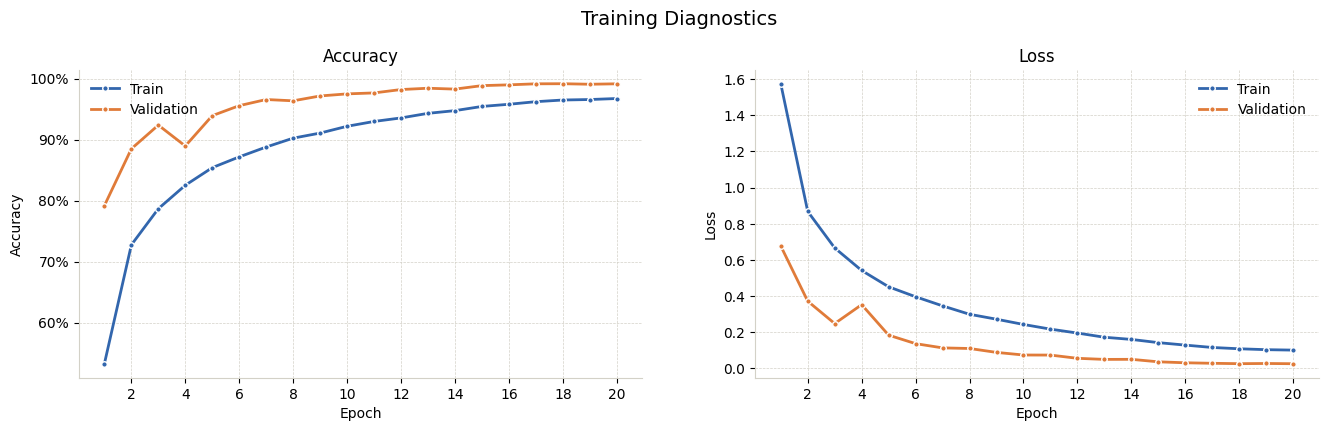

In [14]:
BLUE, ORANGE, GRAY, BLACK = "#3266ad", "#e07b39", "#88877f", "#000000"

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#d3d1c7",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": "#d3d1c7",
    "grid.linewidth": 0.5,
    "grid.linestyle": "--",
    "xtick.color": BLACK,
    "ytick.color": BLACK,
})

epochs_range = np.arange(1, EPOCHS + 1)
fig = plt.figure(figsize=(16, 4))
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.2)

ax1 = fig.add_subplot(gs[0])
ax1.plot(epochs_range, train_accuracies, color=BLUE, lw=2, label="Train", marker="o", ms=4, mec="white")
ax1.plot(epochs_range, val_accuracies, color=ORANGE, lw=2, label="Validation", marker="o", ms=4, mec="white")
ax1.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy", fontweight="medium")
ax1.legend(frameon=False)

ax2 = fig.add_subplot(gs[1])
ax2.plot(epochs_range, train_losses, color=BLUE, lw=2, label="Train", marker="o", ms=4, mec="white")
ax2.plot(epochs_range, val_losses, color=ORANGE, lw=2, label="Validation", marker="o", ms=4, mec="white")
ax2.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.set_title("Loss", fontweight="medium")
ax2.legend(frameon=False)

fig.suptitle("Training Diagnostics", fontsize=14, fontweight="medium", y=1.03)
plt.savefig("training_curves.pdf", bbox_inches="tight", dpi=150)
plt.show()


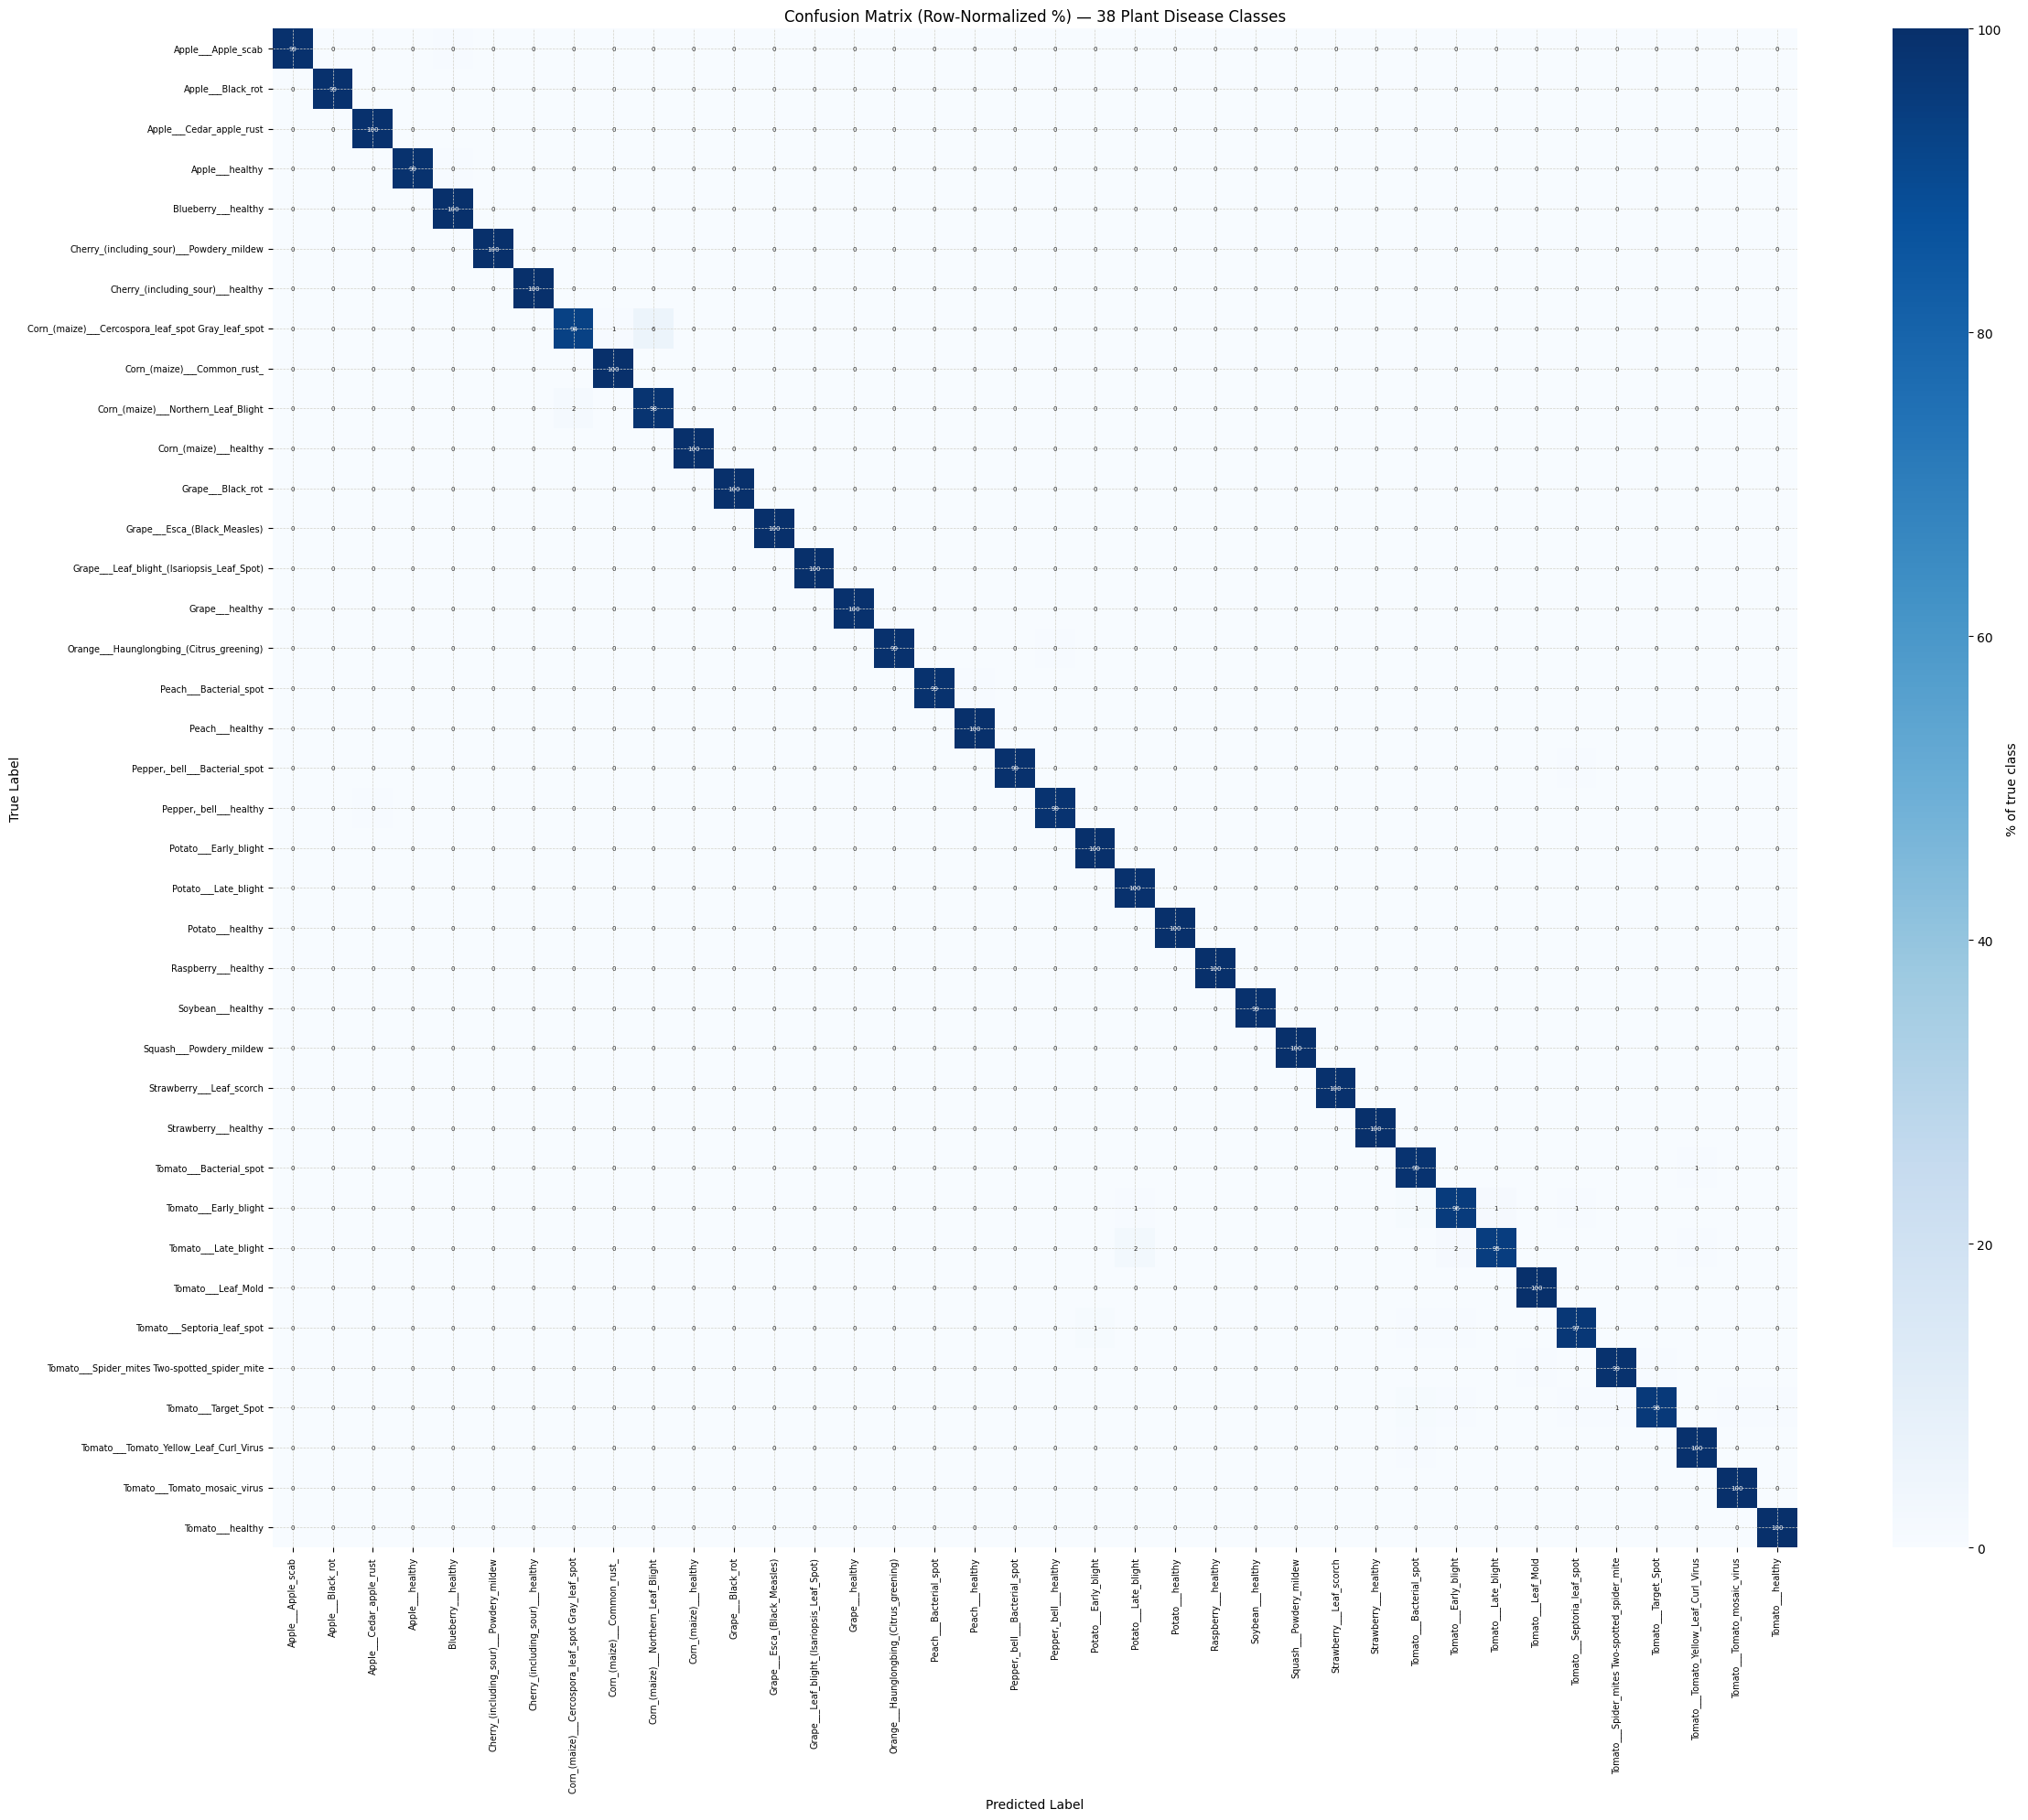

In [15]:
cm = confusion_matrix(all_labels, all_preds)

# Row-normalize to percentages so every cell shows what % of each TRUE class
# was predicted as each class (raw counts would be unreadable across 38 classes).
cm_percent = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(24, 20))
sns.heatmap(
    cm_percent, cmap='Blues', xticklabels=class_names, yticklabels=class_names,
    cbar=True, annot=True, fmt='.0f', annot_kws={"size": 5},
    cbar_kws={'label': '% of true class'}
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix (Row-Normalized %) — {num_classes} Plant Disease Classes')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig("confusion_matrix.pdf", bbox_inches="tight", dpi=150)
plt.show()


Showing 10 misclassified examples (out of 22+ found in the scanned batches)


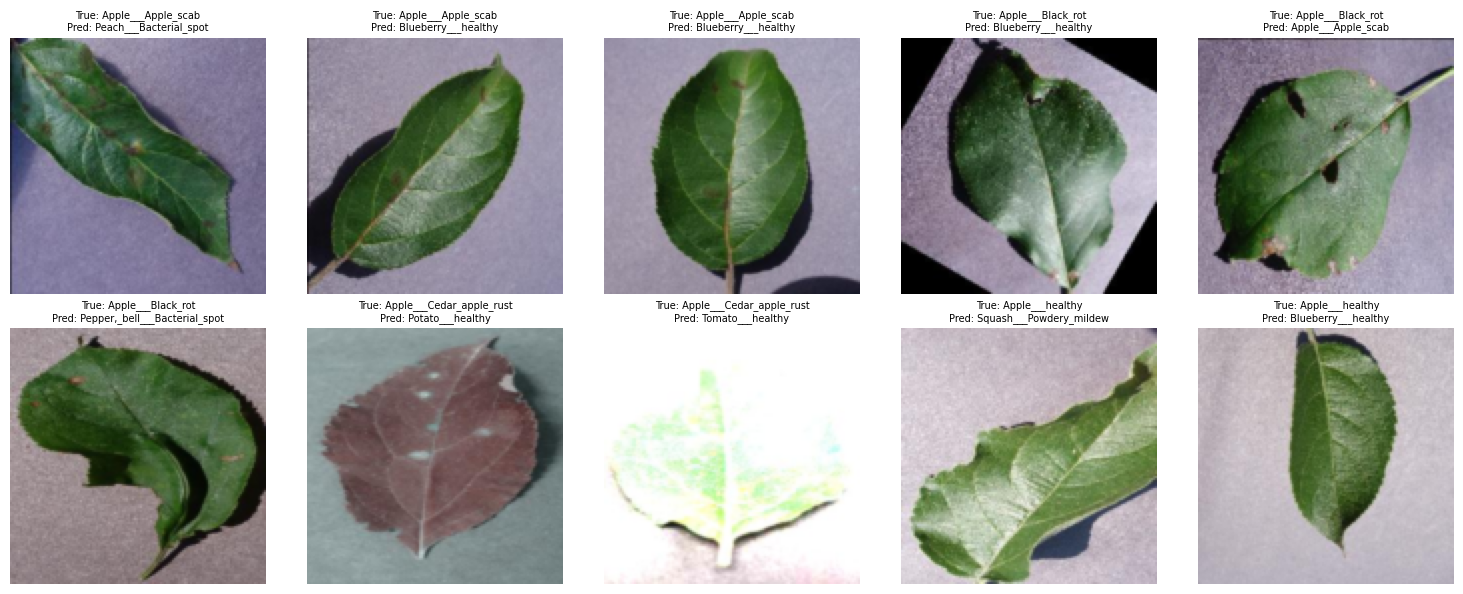

In [16]:
# A sample of misclassified images helps illustrate failure modes qualitatively
misclassified = []
with torch.no_grad():
    for images, labels in test_loader:
        images_dev = images.to(device)
        outputs = model(images_dev)
        _, preds = torch.max(outputs, 1)
        preds = preds.cpu()
        for img, true, pred in zip(images, labels, preds):
            if true != pred:
                misclassified.append((img, true.item(), pred.item()))
        if len(misclassified) >= 20:
            break

print(f"Showing {min(len(misclassified), 10)} misclassified examples "
      f"(out of {len(misclassified)}+ found in the scanned batches)")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, (img, true, pred) in zip(axes.flat, misclassified[:10]):
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(f"True: {class_names[true]}\nPred: {class_names[pred]}", fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 8. Analysis & Discussion of Results

In [17]:
per_class_f1 = report_df.iloc[:num_classes]['f1-score']
best_classes = per_class_f1.sort_values(ascending=False).head(5)
worst_classes = per_class_f1.sort_values(ascending=True).head(5)

print("Top 5 best-performing classes (by F1-score):")
print(best_classes.to_string())
print("\nBottom 5 worst-performing classes (by F1-score):")
print(worst_classes.to_string())


Top 5 best-performing classes (by F1-score):
Cherry_(including_sour)___Powdery_mildew      1.000000
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)    1.000000
Strawberry___healthy                          1.000000
Grape___Esca_(Black_Measles)                  0.998957
Grape___Black_rot                             0.998942

Bottom 5 worst-performing classes (by F1-score):
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot    0.956413
Tomato___Late_blight                                  0.962719
Tomato___Early_blight                                 0.964286
Corn_(maize)___Northern_Leaf_Blight                   0.966942
Tomato___Target_Spot                                  0.975610


### Discussion

The model reached **99.04% test accuracy** (weighted F1 = 0.9904) on the held-out test set,
consistent with the best validation accuracy of 99.17% (epoch 18), showing good generalization
with no major overfitting.

Final training accuracy (96.75%) was lower than validation/test accuracy — this is expected,
since training images are heavily augmented while validation/test images are not, making
training intentionally harder than evaluation.

**Best classes:** Cherry Powdery Mildew, Grape Leaf Blight (Isariopsis), and Strawberry healthy
all reached a perfect 100% F1-score, followed closely by Grape Esca/Black Measles (99.90%) and
Grape Black Rot (99.89%) — these classes have very distinct visual patterns.

**Weakest classes:** Corn Cercospora/Gray Leaf Spot (95.64%), Tomato Late Blight (96.27%),
Tomato Early Blight (96.43%), Corn Northern Leaf Blight (96.69%), and Tomato Target Spot
(97.56%) — still strong overall, but these diseases look visually similar to others on the
same crop, causing most of the confusion seen in the confusion matrix.

## 9. Conclusions & Future Work

A custom CNN trained from scratch achieved **99.04% test accuracy** on this 38-class plant
disease dataset, using augmentation, dropout, and batch norm to generalize well without
overfitting. Errors were concentrated among visually similar diseases on the same crop
(especially Tomato blight/spot varieties and Corn leaf-disease varieties), not random
mistakes — showing the model learned meaningful, semantically sensible features.

**Future work:**
- Compare with transfer learning (ResNet/EfficientNet)
- Add Grad-CAM for explainability
- Test on real field images, not just lab-style photos
- Try ensembling models to fix the remaining confusable disease pairs

## 10. Save Trained Model

In [18]:
FINAL_MODEL_PATH = "plant_disease_cnn_final.pth"
torch.save(model.state_dict(), FINAL_MODEL_PATH)

size_mb = os.path.getsize(FINAL_MODEL_PATH) / (1024 ** 2)
print(f"Saved model to '{FINAL_MODEL_PATH}' ({size_mb:.2f} MB)")
print(f"(Best checkpoint during training was also saved to '{BEST_MODEL_PATH}')")

# --- Reload check, following the course's save/load example pattern ---
reloaded_model = PlantDiseaseCNN(num_classes).to(device)
reloaded_model.load_state_dict(torch.load(FINAL_MODEL_PATH, map_location=device))
reloaded_model.eval()
print("\nModel successfully reloaded from disk:")
summary(reloaded_model, input_size=(3, IMG_SIZE, IMG_SIZE))


Saved model to 'plant_disease_cnn_final.pth' (10.34 MB)
(Best checkpoint during training was also saved to 'best_plant_disease_cnn.pth')

Model successfully reloaded from disk:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
       BatchNorm2d-2         [-1, 32, 128, 128]              64
              ReLU-3         [-1, 32, 128, 128]               0
            Conv2d-4         [-1, 32, 128, 128]           9,248
       BatchNorm2d-5         [-1, 32, 128, 128]              64
              ReLU-6         [-1, 32, 128, 128]               0
         MaxPool2d-7           [-1, 32, 64, 64]               0
         Dropout2d-8           [-1, 32, 64, 64]               0
            Conv2d-9           [-1, 64, 64, 64]          18,496
      BatchNorm2d-10           [-1, 64, 64, 64]             128
             ReLU-11           [-1, 64, 64, 64]       